# Comparison of Results: Config A vs Config B

## 1. Imports

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Import Results 

In [15]:
comparison_df = pd.read_excel(
    "ddqn_ppo_results.xlsx",
    sheet_name="Overall Comparison"
)

comparison_df

,Algorithm,Mean Return,Mean Return Std,Survival Rate,Survival Rate Std,Mean Length,Mean Length Std,Training Episodes,Eval Seeds,Eval Episodes / Seed,Best Trial,Best Checkpoint Episode,Checkpoint Survival,Checkpoint Return,buffer_size
0,Random,0.560656,0.001085,0.653200,0.000871,-,-,0,5,50000,-,-,-,-,-
1,Double DQN,0.576218,0.002349,0.663480,0.002341,9.409644,0.026281,50000,5,50000,NaN,28000,0.699,0.610572,100000
2,PPO,0.656004,0.002557,0.677492,0.002535,7.376944,0.023816,50000,5,50000,NaN,46000,0.713,0.691507,N/A (on-policy)


In [16]:
config_a_df = pd.read_excel(
    "config_a_results.xlsx",
    sheet_name="Overall Comparison"
)

config_a_df

,Algorithm,Mean Return,Survival Rate,Mean Length,Runtime (s),Convergence Type,Convergence Count,Value Updates
0,Random,0.590075,0.6940,10.32400,NaN,NaN,NaN,NaN
1,Policy Iteration,0.786502,0.8252,9.84536,6.025020,Policy improvement rounds,4.0,736.0
2,Value Iteration,0.786502,0.8252,9.84536,29.489921,Bellman updates,81.0,81.0


## 3. Comparison 

In [22]:
config_a_df["Configuration"] = "Config A"
comparison_df["Configuration"] = "Config B"

comparison_df["Mean Length"] = pd.to_numeric(
    comparison_df["Mean Length"],
    errors="coerce"
)

combined_df = pd.concat(
    [
        config_a_df[
            ["Configuration", "Algorithm", "Mean Return",
             "Survival Rate", "Mean Length"]
        ],
        comparison_df[
            ["Configuration", "Algorithm", "Mean Return",
             "Survival Rate", "Mean Length"]
        ]
    ],
    ignore_index=True
)

display(combined_df)

,Configuration,Algorithm,Mean Return,Survival Rate,Mean Length
0,Config A,Random,0.590075,0.694000,10.324000
1,Config A,Policy Iteration,0.786502,0.825200,9.845360
2,Config A,Value Iteration,0.786502,0.825200,9.845360
3,Config B,Random,0.560656,0.653200,NaN
4,Config B,Double DQN,0.576218,0.663480,9.409644
5,Config B,PPO,0.656004,0.677492,7.376944


In [23]:
combined_df["Label"] = (
    combined_df["Algorithm"]
    + " ("
    + combined_df["Configuration"]
    + ")"
)

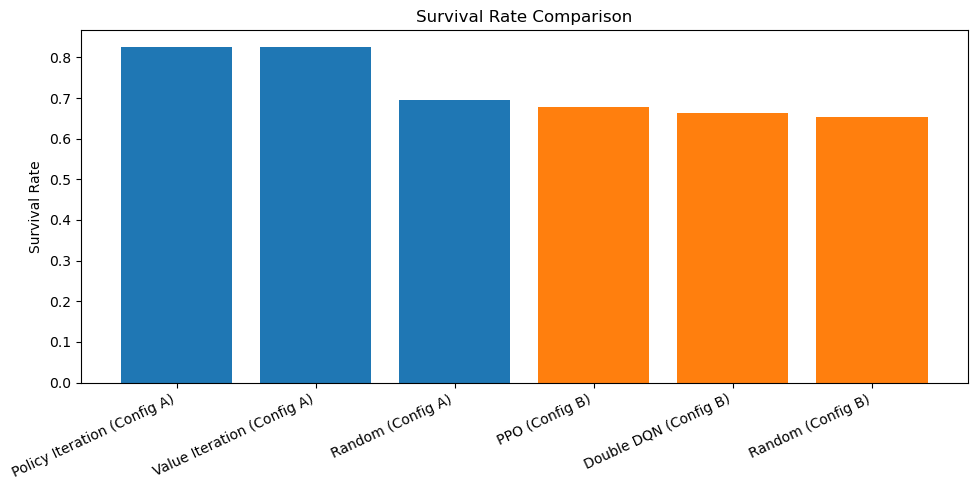

In [24]:
combined_df = combined_df.sort_values(
    "Survival Rate",
    ascending=False
)

colors = combined_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    combined_df["Label"],
    combined_df["Survival Rate"],
    color=colors
)

plt.ylabel("Survival Rate")
plt.title("Survival Rate Comparison")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

The results show a clear performance difference between the two configurations. Policy Iteration and Value Iteration achieved the highest survival rate (82.5%) and converged to the same optimal policy. In Configuration B, both PPO and Double DQN outperformed the random baseline, demonstrating successful learning in the more challenging continuous observation setting. However, their performance remained below that of the model-based approaches, highlighting the advantage of having access to the full MDP model in Configuration A.

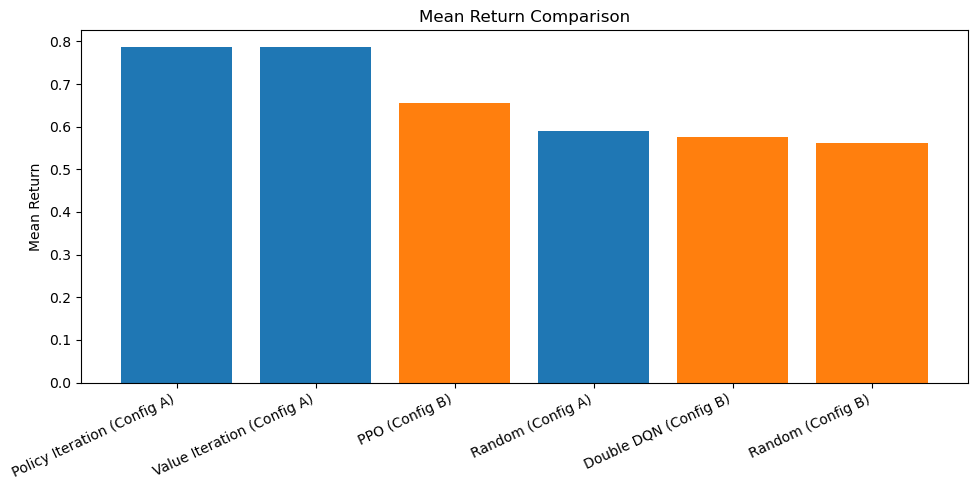

In [25]:
combined_df = combined_df.sort_values(
    "Mean Return",
    ascending=False
)

colors = combined_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    combined_df["Label"],
    combined_df["Mean Return"],
    color=colors
)

plt.ylabel("Mean Return")
plt.title("Mean Return Comparison")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

Although Configuration A achieved substantially higher returns, the difference is less pronounced than in the survival-rate comparison. This suggests that the deep RL agents were able to learn reasonably efficient treatment strategies, even if they could not match the overall performance of the model-based methods.

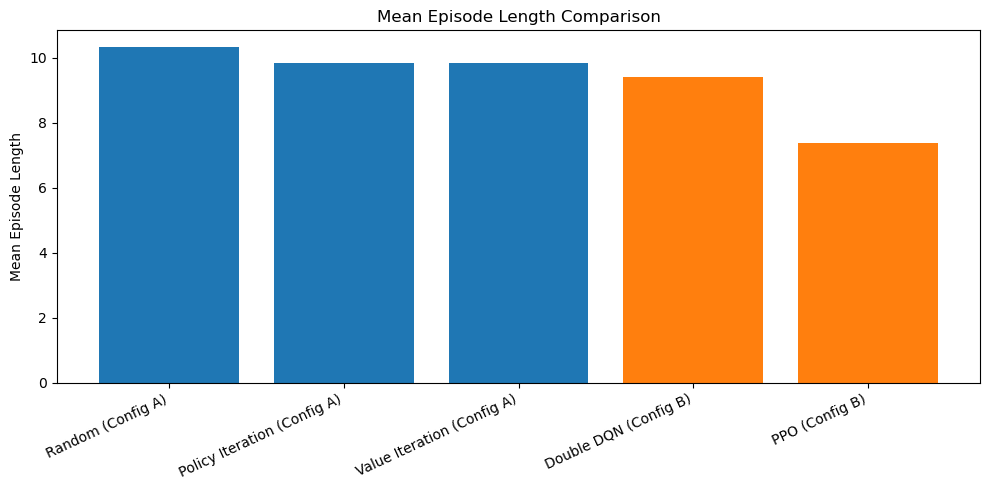

In [30]:
combined_df = combined_df.sort_values(
    "Mean Length",
    ascending=False
)

colors = combined_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    combined_df["Label"],
    combined_df["Mean Length"],
    color=colors
)

plt.ylabel("Mean Episode Length")
plt.title("Mean Episode Length Comparison")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

While Configuration B achieved lower survival rates, the difference in mean return was noticeably smaller. This suggests that the deep RL agents were able to compensate partly through more efficient treatment decisions, particularly PPO, which achieved the shortest average episode length.

In [31]:
random_a = combined_df[
    (combined_df["Configuration"] == "Config A") &
    (combined_df["Algorithm"] == "Random")
].iloc[0]

random_b = combined_df[
    (combined_df["Configuration"] == "Config B") &
    (combined_df["Algorithm"] == "Random")
].iloc[0]

combined_df["Return Improvement (%)"] = combined_df.apply(
    lambda row:
    ((row["Mean Return"] - random_a["Mean Return"]) / random_a["Mean Return"] * 100)
    if row["Configuration"] == "Config A"
    else
    ((row["Mean Return"] - random_b["Mean Return"]) / random_b["Mean Return"] * 100),
    axis=1
)

combined_df["Survival Improvement (%)"] = combined_df.apply(
    lambda row:
    ((row["Survival Rate"] - random_a["Survival Rate"]) / random_a["Survival Rate"] * 100)
    if row["Configuration"] == "Config A"
    else
    ((row["Survival Rate"] - random_b["Survival Rate"]) / random_b["Survival Rate"] * 100),
    axis=1
)

combined_df["Combined Improvement (%)"] = (
    combined_df["Return Improvement (%)"]
    + combined_df["Survival Improvement (%)"]
)

plot_df = combined_df[
    combined_df["Algorithm"] != "Random"
].copy()

plot_df["Label"] = (
    plot_df["Algorithm"] + " (" + plot_df["Configuration"] + ")"
)

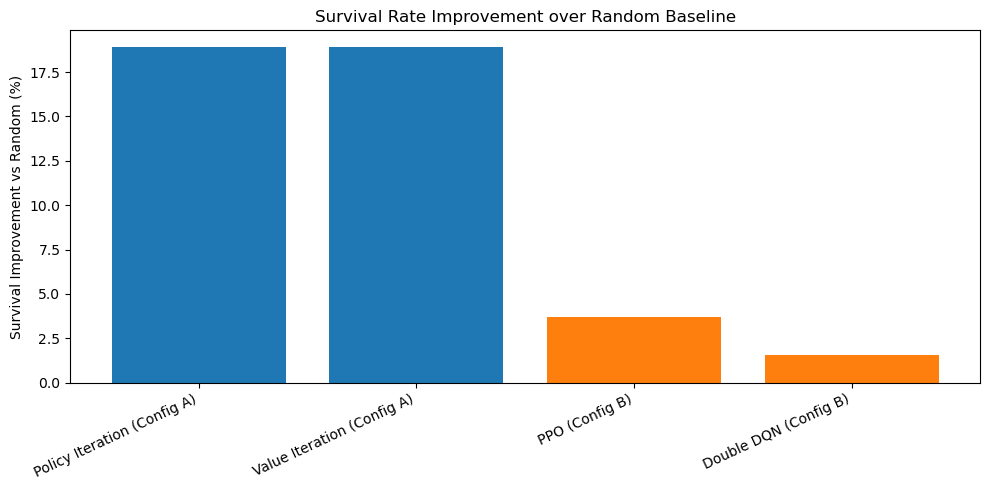

In [29]:
plot_df = plot_df.sort_values(
    "Survival Improvement (%)",
    ascending=False
)

colors = plot_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Label"],
    plot_df["Survival Improvement (%)"],
    color=colors
)

plt.ylabel("Survival Improvement vs Random (%)")
plt.title("Survival Rate Improvement over Random Baseline")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

Compared to their respective random baselines, all learning algorithms achieved positive survival-rate improvements. Policy Iteration and Value Iteration increased survival by almost 19%, while PPO and Double DQN achieved smaller but consistent gains in the more challenging continuous observation setting. These results confirm that both configurations were able to learn treatment policies that outperform random decision making.

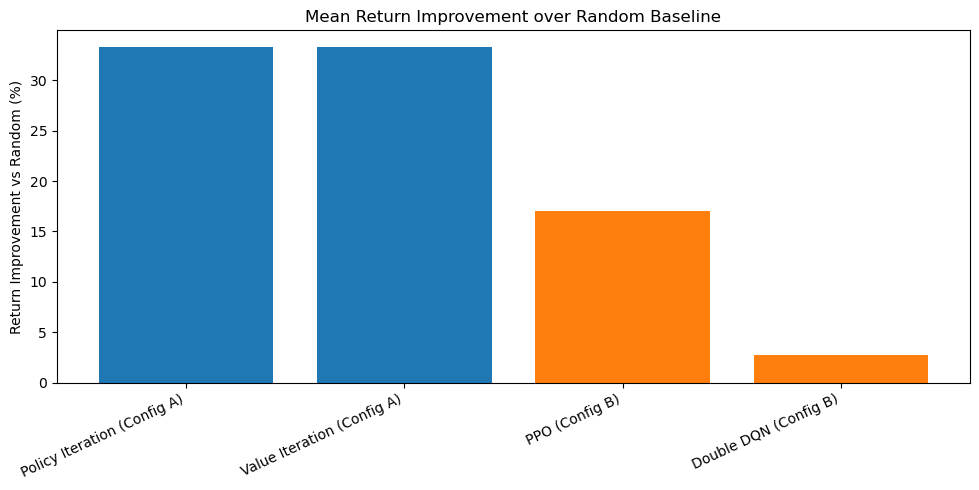

In [28]:
plot_df = plot_df.sort_values(
    "Return Improvement (%)",
    ascending=False
)

colors = plot_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Label"],
    plot_df["Return Improvement (%)"],
    color=colors
)

plt.ylabel("Return Improvement vs Random (%)")
plt.title("Mean Return Improvement over Random Baseline")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

A similar pattern can be observed for mean return. However, PPO achieved a substantially larger gain than Double DQN

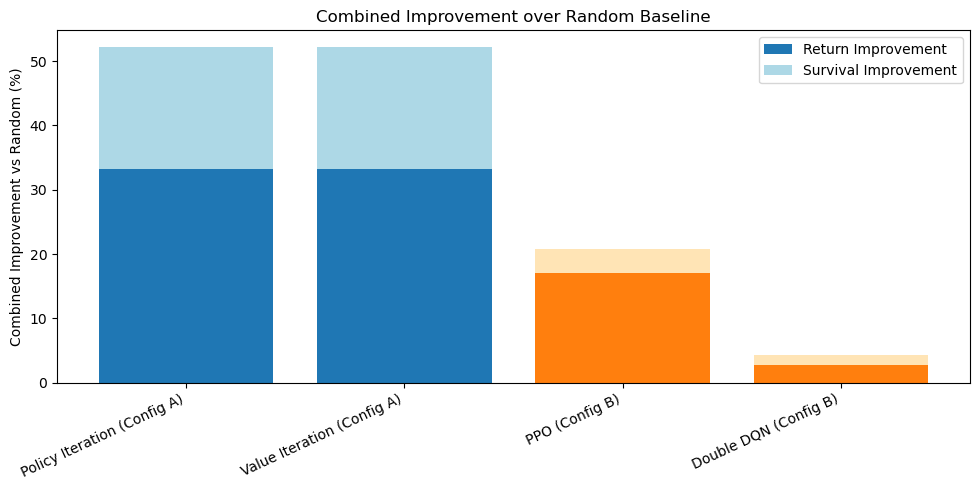

In [32]:
plot_df = plot_df.sort_values(
    "Combined Improvement (%)",
    ascending=False
)

return_colors = plot_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

survival_colors = plot_df["Configuration"].map({
    "Config A": "lightblue",
    "Config B": "moccasin"
})

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Label"],
    plot_df["Return Improvement (%)"],
    color=return_colors,
    label="Return Improvement"
)

plt.bar(
    plot_df["Label"],
    plot_df["Survival Improvement (%)"],
    bottom=plot_df["Return Improvement (%)"],
    color=survival_colors,
    label="Survival Improvement"
)

plt.ylabel("Combined Improvement vs Random (%)")
plt.title("Combined Improvement over Random Baseline")
plt.xticks(rotation=25, ha="right")

plt.legend()

plt.tight_layout()

The results emphasise the difference between the two configurations. Configuration A achieved substantially larger improvements over its random baseline, demonstrating the benefit of complete environment knowledge and model-based optimisation. While Configuration B also improved upon random behaviour, the smaller gains reflect the greater complexity of learning directly from experience in a continuous observation space.